/tmp/ipykernel_55/1730870448.py:30: RuntimeWarning: invalid value encountered in log
  mu_tot = -np.log(n_trans / n_incident) / thickness


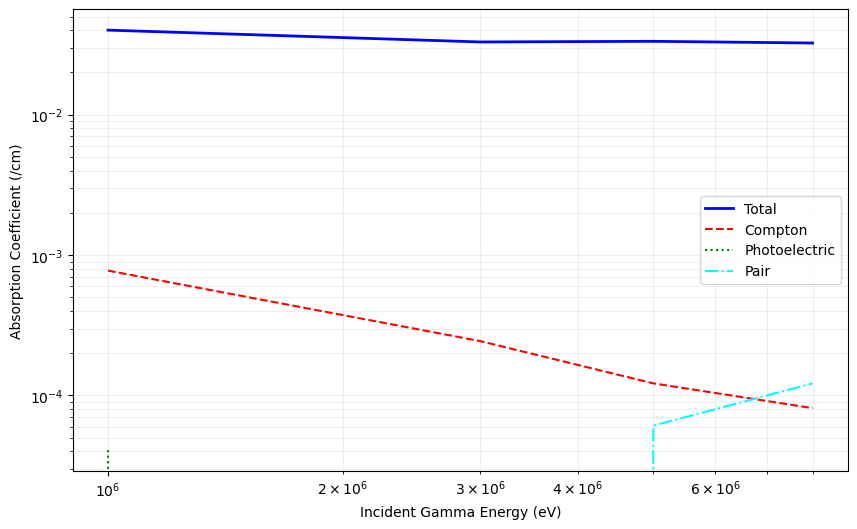

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

# CONFIGURATION
# Update these IDs based on your findings from Step 2
ID_PHOTO = 2012   # Example ID for photoelectric
ID_COMPT = 2013    # Example ID for compton
ID_PAIR  = 2014    # Example ID for pair production

files = {
    1e6: "1MeV_gamma.root",
    3e6: "3MeV_gamma.root",
    5e6: "5MeV_gamma.root",
    8e6: "8MeV_gamma.root",
    10e6: "10MeVgamma.root"
}

def calculate_mu(file_path, n_incident=50000, thickness=1.0):
    with uproot.open(file_path) as f:
        tree = f["t"]
        pro_raw = tree["pro"].array(library="np")
        pro = np.concatenate(pro_raw).ravel()
        
        # Total interactions recorded
        n_interact = len(pro)
        n_trans = n_incident - n_interact
        
        # Total mu
        mu_tot = -np.log(n_trans / n_incident) / thickness
        
       # Component mus using count_nonzero to avoid ambiguity errors
        mu_p  = (np.count_nonzero(pro == ID_PHOTO) / n_interact) * mu_tot if n_interact > 0 else 0
        mu_c  = (np.count_nonzero(pro == ID_COMPT) / n_interact) * mu_tot if n_interact > 0 else 0
        mu_pp = (np.count_nonzero(pro == ID_PAIR) / n_interact) * mu_tot if n_interact > 0 else 0
        return mu_tot, mu_p, mu_c, mu_pp

# Data Collection
energies = sorted(files.keys())
results = {"tot": [], "p": [], "c": [], "pp": []}

for e in energies:
    mt, mp, mc, mpp = calculate_mu(files[e])
    results["tot"].append(mt)
    results["p"].append(mp)
    results["c"].append(mc)
    results["pp"].append(mpp)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(energies, results["tot"], 'b-', label='Total', lw=2)
plt.plot(energies, results["c"], 'r--', label='Compton')
plt.plot(energies, results["p"], 'g:', label='Photoelectric')
plt.plot(energies, results["pp"], 'cyan', linestyle='-.', label='Pair')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Incident Gamma Energy (eV)')
plt.ylabel('Absorption Coefficient (/cm)')
plt.grid(True, which="both", alpha=0.2)
plt.legend()
plt.show()